  CUSTOMER PURCHASE BEHAVIOR ANALYSIS
  Dataset: UCI Online Retail II (Real)

✅ Raw data loaded: 1,067,371 rows x 8 columns
   Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

── DATA CLEANING ──
  Cancelled orders removed : 19,494
  Rows missing Customer ID : 242,257 (removed)
  Rows remaining after cleaning : 805,549

   Date range : 2009-12-01 → 2011-12-09
   Unique customers : 5,878
   Unique products  : 4,631
   Countries        : 41

── EDA SUMMARY ──
       TotalAmount   Quantity      Price
count    805549.00  805549.00  805549.00
mean         22.03      13.29       3.21
std         224.04     143.63      29.20
min           0.00       1.00       0.00
25%           4.95       2.00       1.25
50%          11.85       5.00       1.95
75%          19.50      12.00       3.75
max      168469.60   80995.00   10953.50

── TOP METRICS ──
  Total Revenue   : £17,743,429.18
  Avg Order Value : £479.95

  Top 10 Countries by R

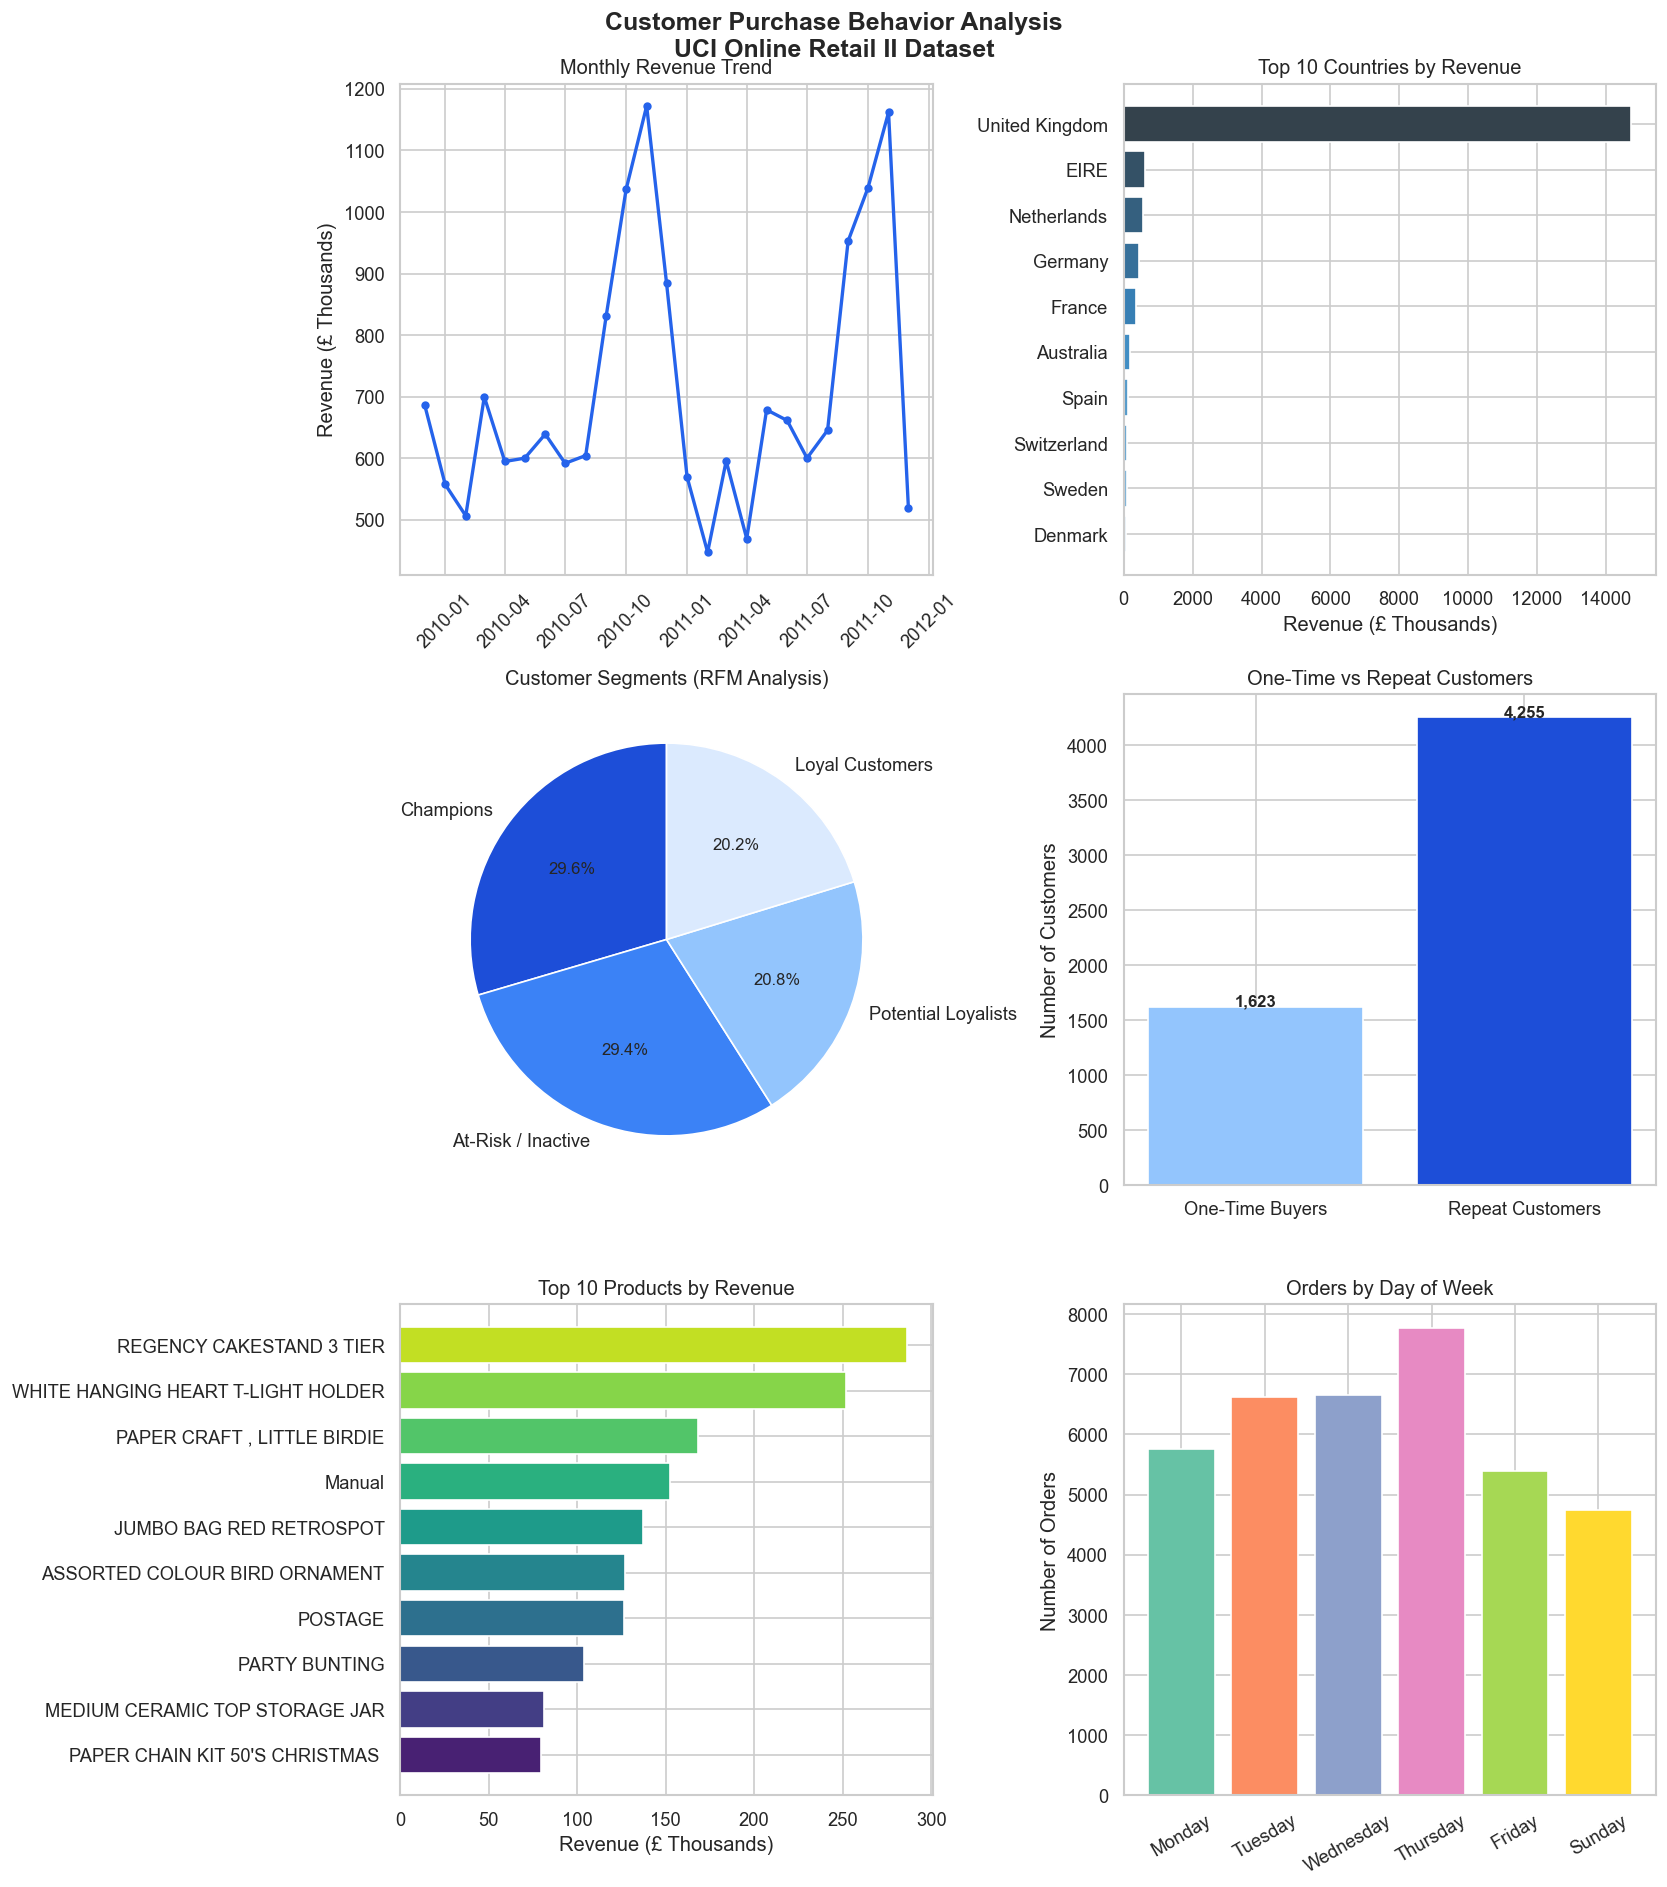

In [4]:
"""
 PROJECT: Customer Purchase Behavior Analysis

 """


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

#  1. LOAD DATA
print("=" * 60)
print("  CUSTOMER PURCHASE BEHAVIOR ANALYSIS")
print("  Dataset: UCI Online Retail II (Real)")
print("=" * 60)

# The real dataset file is online_retail_II.csv
df = pd.read_csv("online_retail_II.csv", encoding="ISO-8859-1")

print(f"\n✅ Raw data loaded: {len(df):,} rows x {df.shape[1]} columns")
print(f"   Columns: {list(df.columns)}")

# 2. DATA CLEANING
print("\n── DATA CLEANING ──")

# Real dataset columns: Invoice, StockCode, Description, Quantity,
#                       InvoiceDate, Price, Customer ID, Country

# Parse dates
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Remove cancelled orders (Invoice starts with 'C')
cancelled = df[df["Invoice"].astype(str).str.startswith("C")]
df = df[~df["Invoice"].astype(str).str.startswith("C")]
print(f"  Cancelled orders removed : {len(cancelled):,}")

# Remove rows with missing Customer ID
missing_cust = df["Customer ID"].isnull().sum()
df.dropna(subset=["Customer ID"], inplace=True)
print(f"  Rows missing Customer ID : {missing_cust:,} (removed)")

# Remove rows with negative or zero Quantity/Price
df = df[(df["Quantity"] > 0) & (df["Price"] > 0)]
print(f"  Rows remaining after cleaning : {len(df):,}")

# Create TotalAmount column
df["TotalAmount"] = df["Quantity"] * df["Price"]

# Derived time columns
df["Year"]      = df["InvoiceDate"].dt.year
df["Month"]     = df["InvoiceDate"].dt.month
df["MonthName"] = df["InvoiceDate"].dt.strftime("%b")
df["DayName"]   = df["InvoiceDate"].dt.day_name()

print(f"\n   Date range : {df['InvoiceDate'].min().date()} → {df['InvoiceDate'].max().date()}")
print(f"   Unique customers : {df['Customer ID'].nunique():,}")
print(f"   Unique products  : {df['StockCode'].nunique():,}")
print(f"   Countries        : {df['Country'].nunique()}")

# 3. EDA SUMMARY 
print("\n── EDA SUMMARY ──")
print(df[["TotalAmount", "Quantity", "Price"]].describe().round(2))

# 4. TOP METRICS 
print("\n── TOP METRICS ──")
total_revenue = df["TotalAmount"].sum()
avg_order     = df.groupby("Invoice")["TotalAmount"].sum().mean()
print(f"  Total Revenue   : £{total_revenue:,.2f}")
print(f"  Avg Order Value : £{avg_order:,.2f}")

print("\n  Top 10 Countries by Revenue:")
country_rev = df.groupby("Country")["TotalAmount"].sum().sort_values(ascending=False).head(10)
for country, rev in country_rev.items():
    print(f"    {country:<30} £{rev:>12,.2f}")

print("\n  Top 10 Products by Revenue:")
prod_rev = df.groupby("Description")["TotalAmount"].sum().sort_values(ascending=False).head(10)
for prod, rev in prod_rev.items():
    print(f"    {str(prod):<45} £{rev:>10,.2f}")

# 5. REPEAT CUSTOMER ANALYSIS
print("\n── REPEAT CUSTOMER ANALYSIS ──")
purchase_counts = df.groupby("Customer ID")["Invoice"].nunique()
repeat = (purchase_counts > 1).sum()
one_time = (purchase_counts == 1).sum()
total_cust = len(purchase_counts)
print(f"  Repeat customers (2+ orders) : {repeat:,} ({repeat/total_cust*100:.1f}%)")
print(f"  One-time buyers              : {one_time:,} ({one_time/total_cust*100:.1f}%)")

# 6. RFM SEGMENTATION
print("\n── RFM SEGMENTATION ──")
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df.groupby("Customer ID").agg(
    Recency   = ("InvoiceDate",  lambda x: (snapshot_date - x.max()).days),
    Frequency = ("Invoice",      "nunique"),
    Monetary  = ("TotalAmount",  "sum")
).reset_index()

rfm["R_score"] = pd.qcut(rfm["Recency"],   4, labels=[4, 3, 2, 1]).astype(int)
rfm["F_score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)
rfm["M_score"] = pd.qcut(rfm["Monetary"],  4, labels=[1, 2, 3, 4]).astype(int)
rfm["RFM_Score"] = rfm["R_score"] + rfm["F_score"] + rfm["M_score"]

def segment(score):
    if score >= 10: return "Champions"
    elif score >= 8: return "Loyal Customers"
    elif score >= 6: return "Potential Loyalists"
    else:            return "At-Risk / Inactive"

rfm["Segment"] = rfm["RFM_Score"].apply(segment)

seg_summary = rfm.groupby("Segment").agg(
    Customers     = ("Customer ID", "count"),
    Avg_Recency   = ("Recency",     "mean"),
    Avg_Frequency = ("Frequency",   "mean"),
    Avg_Monetary  = ("Monetary",    "mean")
).round(1)

print(seg_summary.to_string())

# 7. MONTHLY REVENUE TREND
monthly = df.groupby(["Year", "Month"])["TotalAmount"].sum().reset_index()
monthly["Period"] = pd.to_datetime(monthly[["Year", "Month"]].assign(day=1))
# 8. VISUALISATIONS 
fig, axes = plt.subplots(3, 2, figsize=(14, 16))
fig.suptitle("Customer Purchase Behavior Analysis\nUCI Online Retail II Dataset",
             fontsize=15, fontweight="bold", y=0.98)

# 8.1 Monthly Revenue Trend
axes[0,0].plot(monthly["Period"], monthly["TotalAmount"]/1000,
               marker="o", color="#2563eb", linewidth=2, markersize=4)
axes[0,0].set_title("Monthly Revenue Trend")
axes[0,0].set_ylabel("Revenue (£ Thousands)")
axes[0,0].tick_params(axis="x", rotation=45)

# 8.2 Top 10 Countries by Revenue (excluding UK to show others clearly)
top_countries = country_rev.head(10)
axes[0,1].barh(top_countries.index[::-1], top_countries.values[::-1]/1000,
               color=sns.color_palette("Blues_d", 10))
axes[0,1].set_title("Top 10 Countries by Revenue")
axes[0,1].set_xlabel("Revenue (£ Thousands)")

# 8.3 Customer Segments Pie
seg_counts = rfm["Segment"].value_counts()
axes[1,0].pie(seg_counts, labels=seg_counts.index, autopct="%1.1f%%",
              colors=["#1d4ed8","#3b82f6","#93c5fd","#dbeafe"], startangle=90)
axes[1,0].set_title("Customer Segments (RFM Analysis)")

# 8.4 Repeat vs One-time
axes[1,1].bar(["One-Time Buyers", "Repeat Customers"], [one_time, repeat],
              color=["#93c5fd", "#1d4ed8"])
axes[1,1].set_title("One-Time vs Repeat Customers")
axes[1,1].set_ylabel("Number of Customers")
for i, v in enumerate([one_time, repeat]):
    axes[1,1].text(i, v + 5, f"{v:,}", ha="center", fontweight="bold")

# 8.5 Top 10 Products by Revenue
top_prods = df.groupby("Description")["TotalAmount"].sum().sort_values(ascending=False).head(10)
axes[2,0].barh([str(p)[:35] for p in top_prods.index[::-1]],
               top_prods.values[::-1]/1000,
               color=sns.color_palette("viridis", 10))
axes[2,0].set_title("Top 10 Products by Revenue")
axes[2,0].set_xlabel("Revenue (£ Thousands)")

# 8.6 Orders by Day of Week
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Sunday"]
day_counts = df[df["DayName"].isin(day_order)].groupby("DayName")["Invoice"].nunique()
day_counts = day_counts.reindex(day_order, fill_value=0)
axes[2,1].bar(day_counts.index, day_counts.values,
              color=sns.color_palette("Set2", len(day_counts)))
axes[2,1].set_title("Orders by Day of Week")
axes[2,1].set_ylabel("Number of Orders")
axes[2,1].tick_params(axis="x", rotation=30)

plt.tight_layout()

# 9. EXPORT
rfm.to_csv("rfm_segments_output.csv", index=False)

print("\n" + "=" * 60)
print("  ANALYSIS COMPLETE")
print("=" * 60)